# Chapter 5: Analysis of Dynamic Models


> **Source and scope.** This is an original computational companion to Mark M. Meerschaert, *Mathematical Modeling*, 4th ed. (Academic Press, 2013). It follows the chapter structure and reconstructs representative models in Python. It does not reproduce the textbook's prose, figures, or complete exercise sets. Equations, numerical assumptions, and example names are attributed to the book.


This notebook follows Sections 5.1-5.3: eigenvalue tests for continuous and discrete systems, local linearization, and phase portraits.


In [1]:
from __future__ import annotations

import platform
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (8, 4.8)

SEED = 20260731
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "SymPy": sp.__version__,
    "pandas": pd.__version__,
    "Matplotlib": version("matplotlib"),
}, name="version")
display(versions.to_frame())


,version
Python,3.13.5
NumPy,2.3.5
SciPy,1.17.0
SymPy,1.14.0
pandas,2.2.3
Matplotlib,3.10.8


## 5.1 Continuous-time eigenvalue test

An equilibrium is asymptotically stable when every eigenvalue of the Jacobian has negative real part. The test is local and comes from the linear approximation of the vector field.


In [2]:
H, S = sp.symbols("H S", real=True)
competition_ratio = sp.symbols("q", positive=True, real=True)

r1_val, r2_val = sp.Rational(1, 10), sp.Rational(1, 4)
a1_val = r1_val / 10_000
a2_val = r2_val / 6_000
b1_val = a1_val / 2
b2_val = a2_val / 2

f1 = r1_val * H - a1_val * H**2 - b1_val * H * S
f2 = r2_val * S - a2_val * S**2 - b2_val * H * S
coexist = sp.solve([sp.factor(f1 / H), sp.factor(f2 / S)], (H, S), dict=True)[0]
J = sp.Matrix([f1, f2]).jacobian([H, S])
J_eq = sp.simplify(J.subs(coexist))
eigenvalues = list(J_eq.eigenvals().keys())

print("Coexistence equilibrium:")
display(coexist)
print("Jacobian at equilibrium:")
display(J_eq)
print("Eigenvalues:")
display(eigenvalues)

assert all(complex(sp.N(ev)).real < 0 for ev in eigenvalues)


Coexistence equilibrium:


{H: 28000/3, S: 4000/3}

Jacobian at equilibrium:


Matrix([
[-7/75, -7/150],
[-1/36,  -1/18]])

Eigenvalues:


[-67/900 - sqrt(1339)/900, -67/900 + sqrt(1339)/900]

### Sensitivity of stability to competition strength

Set \(b_i=q a_i\). The coexistence equilibrium exists for \(0<q<0.6\) in this parameterization. We scan the largest real part of the Jacobian eigenvalues.


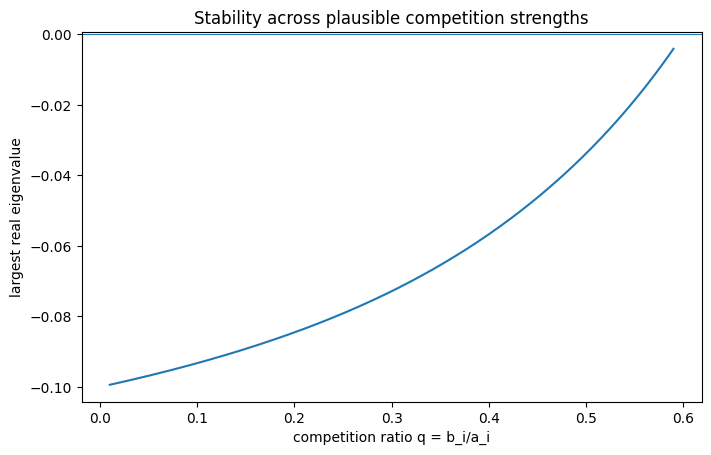

In [3]:
def tree_max_real_eigenvalue(q_value):
    b1 = float(a1_val) * q_value
    b2 = float(a2_val) * q_value
    A = np.array([[float(a1_val), b1], [b2, float(a2_val)]])
    rhs = np.array([float(r1_val), float(r2_val)])
    point = np.linalg.solve(A, rhs)
    h, s = point
    jac = np.array([
        [float(r1_val) - 2 * float(a1_val) * h - b1 * s, -b1 * h],
        [-b2 * s, float(r2_val) - 2 * float(a2_val) * s - b2 * h],
    ])
    return np.max(np.real(np.linalg.eigvals(jac))), point

q_grid = np.linspace(0.01, 0.59, 250)
max_real = np.array([tree_max_real_eigenvalue(qv)[0] for qv in q_grid])

plt.plot(q_grid, max_real)
plt.axhline(0, linewidth=0.8)
plt.xlabel("competition ratio q = b_i/a_i")
plt.ylabel("largest real eigenvalue")
plt.title("Stability across plausible competition strengths")
plt.show()

assert np.all(max_real < 0)


## 5.2 Discrete-time eigenvalue test

For an iteration \(x_{n+1}=G(x_n)\), stability requires every Jacobian eigenvalue to lie inside the unit disk. The docking model gives a clean spectral-radius calculation.


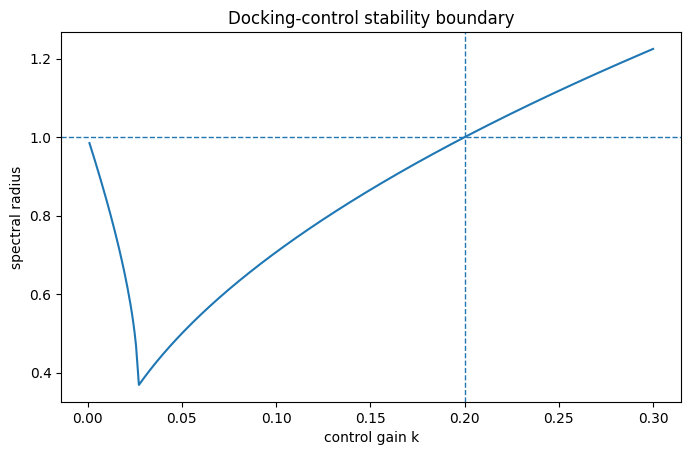

Eigenvalues at k=0.02: [0.644949 0.155051]


In [4]:
def docking_matrix(k, c=5.0, w=10.0):
    return np.array([[1 - k * w, -k * c], [1.0, 0.0]])

k_grid = np.linspace(0.001, 0.30, 400)
spectral_radius = np.array([np.max(np.abs(np.linalg.eigvals(docking_matrix(k)))) for k in k_grid])

plt.plot(k_grid, spectral_radius)
plt.axhline(1, linestyle="--", linewidth=1)
plt.axvline(0.2, linestyle="--", linewidth=1)
plt.xlabel("control gain k")
plt.ylabel("spectral radius")
plt.title("Docking-control stability boundary")
plt.show()

baseline_eigs = np.linalg.eigvals(docking_matrix(0.02))
print("Eigenvalues at k=0.02:", baseline_eigs)
assert np.max(np.abs(baseline_eigs)) < 1
assert np.max(np.abs(np.linalg.eigvals(docking_matrix(0.21)))) > 1


## 5.3 Phase portraits: linear RLC circuit

For the linear circuit model

\[
\begin{bmatrix}x_1'\\x_2'\end{bmatrix}
=
\begin{bmatrix}-4&-1\\3&0\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix},
\]

the eigenvalues are negative, so trajectories approach the origin.


RLC eigenvalues: [-3. -1.]


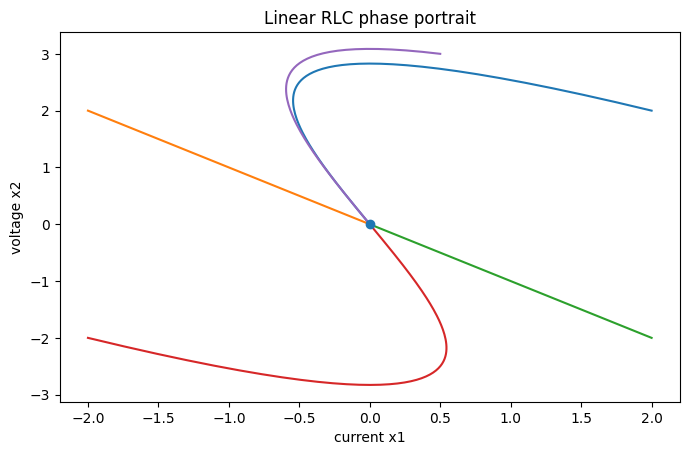

In [5]:
from scipy.linalg import expm

A_rlc = np.array([[-4.0, -1.0], [3.0, 0.0]])
print("RLC eigenvalues:", np.linalg.eigvals(A_rlc))

times = np.linspace(0, 8, 300)
initials = [[2, 2], [-2, 2], [2, -2], [-2, -2], [0.5, 3]]
for initial in initials:
    trajectory = np.array([expm(A_rlc * time) @ np.asarray(initial) for time in times])
    plt.plot(trajectory[:, 0], trajectory[:, 1])
plt.scatter([0], [0], zorder=3)
plt.xlabel("current x1")
plt.ylabel("voltage x2")
plt.title("Linear RLC phase portrait")
plt.show()


### Local linearization of the nonlinear RLC circuit

The nonlinear model is

\[
x_1'=x_1-x_1^3-x_2,\qquad x_2'=x_1.
\]

Its Jacobian at the origin has eigenvalues with positive real part, so the origin is locally unstable. Global behavior is deferred to simulation in Chapter 6.


In [6]:
x1, x2 = sp.symbols("x1 x2", real=True)
nonlinear_vector = sp.Matrix([x1 - x1**3 - x2, x1])
nonlinear_J = nonlinear_vector.jacobian([x1, x2])
origin_J = nonlinear_J.subs({x1: 0, x2: 0})
origin_eigs = list(origin_J.eigenvals().keys())

display(origin_J)
display(origin_eigs)
assert all(complex(sp.N(ev)).real > 0 for ev in origin_eigs)


Matrix([
[1, -1],
[1,  0]])

[1/2 - sqrt(3)*I/2, 1/2 + sqrt(3)*I/2]

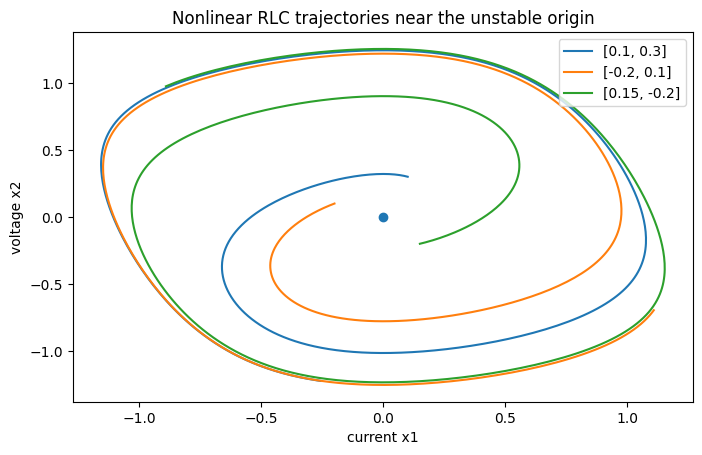

In [7]:
from scipy.integrate import solve_ivp

def nonlinear_rlc(time, state):
    i, v = state
    return [i - i**3 - v, i]

for initial in [[0.1, 0.3], [-0.2, 0.1], [0.15, -0.2]]:
    sol = solve_ivp(nonlinear_rlc, (0, 10), initial, rtol=1e-9, atol=1e-11, max_step=0.02)
    plt.plot(sol.y[0], sol.y[1], label=str(initial))
plt.scatter([0], [0], zorder=3)
plt.xlabel("current x1")
plt.ylabel("voltage x2")
plt.title("Nonlinear RLC trajectories near the unstable origin")
plt.legend()
plt.show()


## Chapter checkpoint

Eigenvalues turn local stability into a matrix calculation. Continuous systems use the left half-plane; discrete systems use the unit disk. Phase portraits then add geometric information that a yes/no stability label cannot provide.
